In [4]:
!pip install -q mlflow dagshub

In [5]:
import os
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

import mlflow
import mlflow.tensorflow
import dagshub

In [6]:
dagshub.init(
    repo_owner="Aryanupadhyay23",
    repo_name="Emotion-Detection-Deep-Learning",
    mlflow=True
)

mlflow.set_experiment("Emotion_EfficientNetB3")

if mlflow.active_run():
    mlflow.end_run()

mlflow.start_run(run_name="EfficientNetB3")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=45f8d8bb-066b-42a4-a555-b66e34d20515&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=2908ea7d7ea561a2c83e08067b5dbf4a572061b84e958d92d8c5d6e93e18903c




Output()

Accessing as Aryanupadhyay23

Initialized MLflow to track repo "Aryanupadhyay23/Emotion-Detection-Deep-Learning"

Repository Aryanupadhyay23/Emotion-Detection-Deep-Learning initialized!

2026/03/04 10:28:18 INFO mlflow.tracking.fluent: Experiment with name 'Emotion_EfficientNetB3' does not exist. Creating a new experiment.


<ActiveRun: >

In [7]:
DATASET_PATH = "/kaggle/input/datasets/sujaykapadnis/emotion-recognition-dataset/dataset"

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 60
SEED = 42

In [8]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

Found 15453 files belonging to 6 classes.
Using 12363 files for training.


I0000 00:00:1772620113.056085      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 15453 files belonging to 6 classes.
Using 3090 files for validation.


In [9]:
train_ds = train_ds.map(
    lambda x,y:(x,tf.one_hot(y,num_classes)),
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = val_ds.map(
    lambda x,y:(x,tf.one_hot(y,num_classes)),
    num_parallel_calls=tf.data.AUTOTUNE
)

In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [11]:
labels=[]

for _,y in train_ds.unbatch():
    labels.append(np.argmax(y.numpy()))

labels=np.array(labels)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

mlflow.log_dict(class_weights,"class_weights.json")

{0: np.float64(2.1264189886480906), 1: np.float64(1.9347417840375587), 2: np.float64(0.6845514950166113), 3: np.float64(0.6415006226650062), 4: np.float64(0.65936), 5: np.float64(2.0982688391038695)}


In [12]:
data_aug = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [13]:
base_model = tf.keras.applications.EfficientNetB3(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE,IMG_SIZE,3)
)

base_model.trainable = False

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [14]:
inputs = keras.Input(shape=(IMG_SIZE,IMG_SIZE,3))

x = data_aug(inputs)

x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dense(256, activation="swish")(x)

x = layers.Dropout(0.5)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 7, 7, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,184,693 (42.67 MB)

 Trainable params: 398,086 (1.52 MB)

 Non-trainable params: 10,786,607 (41.15 MB)

In [15]:
loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

model.compile(
    optimizer=keras.optimizers.Adam(3e-4),
    loss=loss_fn,
    metrics=["accuracy"]
)

In [16]:
callbacks=[

    keras.callbacks.ModelCheckpoint(
        "best_model.keras",
        monitor="val_accuracy",
        save_best_only=True
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3
    )

]

In [17]:
mlflow.tensorflow.autolog(log_models=False)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/60


E0000 00:00:1772620204.338104      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb3_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1772620207.576871     155 cuda_dnn.cc:529] Loaded cuDNN version 91002


387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.3390 - loss: 1.8939

387/387 ━━━━━━━━━━━━━━━━━━━━ 74s 144ms/step - accuracy: 0.3391 - loss: 1.8935 - val_accuracy: 0.5508 - val_loss: 1.2885 - learning_rate: 3.0000e-04
Epoch 2/60
386/387 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.4936 - loss: 1.4191

387/387 ━━━━━━━━━━━━━━━━━━━━ 50s 129ms/step - accuracy: 0.4937 - loss: 1.4189 - val_accuracy: 0.5828 - val_loss: 1.2422 - learning_rate: 3.0000e-04
Epoch 3/60
386/387 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.5259 - loss: 1.2863

...

387/387 ━━━━━━━━━━━━━━━━━━━━ 49s 128ms/step - accuracy: 0.6898 - loss: 0.9544 - val_accuracy: 0.6540 - val_loss: 1.0997 - learning_rate: 8.1000e-06
Epoch 33/60
386/387 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.6832 - loss: 0.9659

387/387 ━━━━━━━━━━━━━━━━━━━━ 50s 130ms/step - accuracy: 0.6832 - loss: 0.9660 - val_accuracy: 0.6547 - val_loss: 1.0990 - learning_rate: 8.1000e-06
Epoch 34/60
387/387 ━━━━━━━━━━━━━━━━━━━━ 43s 111ms/step - accuracy: 0.6819 - loss: 0.9651 - val_accuracy: 0.6537 - val_loss: 1.0998 - learning_rate: 8.1000e-06
Epoch 35/60
386/387 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.6776 - loss: 0.9713

387/387 ━━━━━━━━━━━━━━━━━━━━ 50s 128ms/step - accuracy: 0.6776 - loss: 0.9713 - val_accuracy: 0.6544 - val_loss: 1.0989 - learning_rate: 8.1000e-06
Epoch 36/60
387/387 ━━━━━━━━━━━━━━━━━━━━ 43s 111ms/step - accuracy: 0.6870 - loss: 0.9646 - val_accuracy: 0.6544 - val_loss: 1.0993 - learning_rate: 8.1000e-06
Epoch 37/60
386/387 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.6840 - loss: 0.9572

387/387 ━━━━━━━━━━━━━━━━━━━━ 50s 129ms/step - accuracy: 0.6840 - loss: 0.9572 - val_accuracy: 0.6557 - val_loss: 1.0981 - learning_rate: 8.1000e-06
Epoch 38/60
387/387 ━━━━━━━━━━━━━━━━━━━━ 43s 111ms/step - accuracy: 0.6865 - loss: 0.9629 - val_accuracy: 0.6576 - val_loss: 1.0988 - learning_rate: 8.1000e-06
Epoch 39/60
387/387 ━━━━━━━━━━━━━━━━━━━━ 43s 111ms/step - accuracy: 0.6845 - loss: 0.9599 - val_accuracy: 0.6560 - val_loss: 1.0985 - learning_rate: 8.1000e-06
Epoch 40/60
387/387 ━━━━━━━━━━━━━━━━━━━━ 43s 111ms/step - accuracy: 0.6876 - loss: 0.9500 - val_accuracy: 0.6560 - val_loss: 1.0983 - learning_rate: 8.1000e-06
Epoch 41/60
386/387 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.6915 - loss: 0.9561

387/387 ━━━━━━━━━━━━━━━━━━━━ 48s 125ms/step - accuracy: 0.6915 - loss: 0.9561 - val_accuracy: 0.6560 - val_loss: 1.0975 - learning_rate: 2.4300e-06
Epoch 42/60
387/387 ━━━━━━━━━━━━━━━━━━━━ 43s 110ms/step - accuracy: 0.6924 - loss: 0.9521 - val_accuracy: 0.6553 - val_loss: 1.0978 - learning_rate: 2.4300e-06
Epoch 43/60
387/387 ━━━━━━━━━━━━━━━━━━━━ 43s 110ms/step - accuracy: 0.6817 - loss: 0.9712 - val_accuracy: 0.6563 - val_loss: 1.0980 - learning_rate: 2.4300e-06
Epoch 44/60
387/387 ━━━━━━━━━━━━━━━━━━━━ 43s 111ms/step - accuracy: 0.6847 - loss: 0.9636 - val_accuracy: 0.6550 - val_loss: 1.0979 - learning_rate: 2.4300e-06
Epoch 45/60
387/387 ━━━━━━━━━━━━━━━━━━━━ 43s 110ms/step - accuracy: 0.6902 - loss: 0.9546 - val_accuracy: 0.6560 - val_loss: 1.0981 - learning_rate: 7.2900e-07
Epoch 46/60
387/387 ━━━━━━━━━━━━━━━━━━━━ 43s 110ms/step - accuracy: 0.6888 - loss: 0.9647 - val_accuracy: 0.6566 - val_loss: 1.0977 - learning_rate: 7.2900e-07


In [19]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss=loss_fn,
    metrics=["accuracy"]
)

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/40
387/387 ━━━━━━━━━━━━━━━━━━━━ 70s 133ms/step - accuracy: 0.5184 - loss: 1.2614 - val_accuracy: 0.5780 - val_loss: 1.2467 - learning_rate: 1.0000e-05
Epoch 2/40
387/387 ━━━━━━━━━━━━━━━━━━━━ 48s 123ms/step - accuracy: 0.5563 - loss: 1.1819 - val_accuracy: 0.5981 - val_loss: 1.2106 - learning_rate: 1.0000e-05
Epoch 3/40
387/387 ━━━━━━━━━━━━━━━━━━━━ 47s 122ms/step - accuracy: 0.5700 - loss: 1.1412 - val_accuracy: 0.6142 - val_loss: 1.1794 - learning_rate: 1.0000e-05
Epoch 4/40
387/387 ━━━━━━━━━━━━━━━━━━━━ 48s 123ms/step - accuracy: 0.6011 - loss: 1.0984 - val_accuracy: 0.6243 - val_loss: 1.1625 - learning_rate: 1.0000e-05
Epoch 5/40
387/387 ━━━━━━━━━━━━━━━━━━━━ 47s 122ms/step - accuracy: 0.6235 - loss: 1.0746 - val_accuracy: 0.6385 - val_loss: 1.1397 - learning_rate: 1.0000e-05
Epoch 6/40
387/387 ━━━━━━━━━━━━━━━━━━━━ 47s 123ms/step - accuracy: 0.6271 - loss: 1.0574 - val_accuracy: 0.6437 - val_loss: 1.1262 - learning_rate: 1.0000e-05
Epoch 7/40
387/387 ━━━━━━━━━━━━━━━━━━━━ 47s 12

2026/03/04 11:40:39 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during tensorflow autologging: INVALID_PARAMETER_VALUE: Response: {'error_code': 'INVALID_PARAMETER_VALUE'}


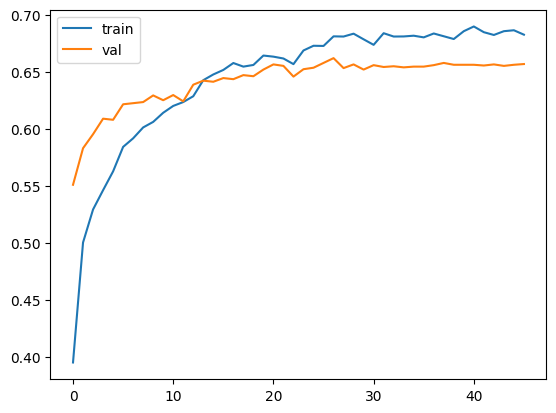

In [20]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.legend(["train","val"])

plt.savefig("training_curve.png")
mlflow.log_artifact("training_curve.png")

plt.show()

In [21]:
y_true=[]
y_pred=[]
y_prob=[]

for x,y in val_ds:

    preds=model.predict(x)

    y_true.extend(np.argmax(y.numpy(),axis=1))
    y_pred.extend(np.argmax(preds,axis=1))
    y_prob.extend(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

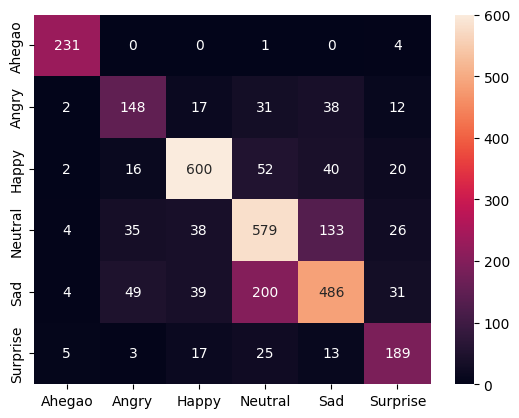

In [22]:
cm = confusion_matrix(y_true,y_pred)

sns.heatmap(cm,annot=True,fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)

plt.savefig("confusion_matrix.png")
mlflow.log_artifact("confusion_matrix.png")

plt.show()

In [23]:
report = classification_report(y_true,y_pred,target_names=class_names)

print(report)

with open("classification_report.txt","w") as f:
    f.write(report)

mlflow.log_artifact("classification_report.txt")

              precision    recall  f1-score   support

      Ahegao       0.93      0.98      0.95       236
       Angry       0.59      0.60      0.59       248
       Happy       0.84      0.82      0.83       730
     Neutral       0.65      0.71      0.68       815
         Sad       0.68      0.60      0.64       809
    Surprise       0.67      0.75      0.71       252

    accuracy                           0.72      3090
   macro avg       0.73      0.74      0.73      3090
weighted avg       0.72      0.72      0.72      3090



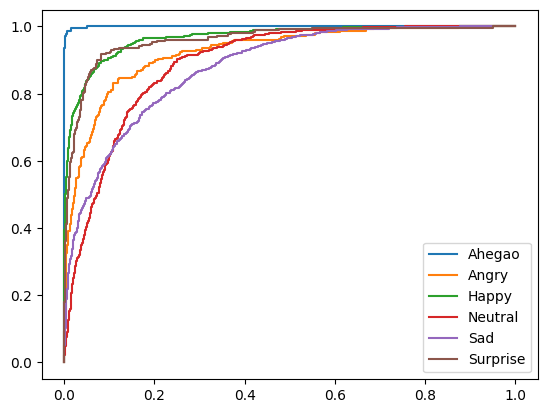

In [24]:
y_true_bin = label_binarize(y_true, classes=range(num_classes))
y_prob = np.array(y_prob)

for i in range(num_classes):

    fpr,tpr,_ = roc_curve(y_true_bin[:,i],y_prob[:,i])

    plt.plot(fpr,tpr,label=class_names[i])

plt.legend()

plt.savefig("roc_curve.png")
mlflow.log_artifact("roc_curve.png")

plt.show()

In [25]:
sample = next(iter(val_ds))[0]

times=[]

for _ in range(5):

    start=time.time()
    model.predict(sample)
    end=time.time()

    times.append((end-start)/len(sample))

latency=np.mean(times)

mlflow.log_metric("latency_per_image",latency)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


In [26]:
best_model = tf.keras.models.load_model("best_model.keras")

mlflow.tensorflow.log_model(best_model,"efficientnetb3_emotion_model")

2026/03/04 11:41:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/04 11:41:12 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


In [27]:
best_model.save("efficientnetb3_model.keras")

size = os.path.getsize("efficientnetb3_model.keras")/(1024*1024)

print("Model size:",size,"MB")

mlflow.log_metric("model_size_mb",size)

Model size: 74.13327503204346 MB


In [28]:
mlflow.end_run()

🏃 View run EfficientNetB3 at: https://dagshub.com/Aryanupadhyay23/Emotion-Detection-Deep-Learning.mlflow/#/experiments/1/runs/5b2b3fa68fe7430e8ec922604e26df4d
🧪 View experiment at: https://dagshub.com/Aryanupadhyay23/Emotion-Detection-Deep-Learning.mlflow/#/experiments/1
